# 1: imports and repository root

In [2]:
from pathlib import Path
from dataclasses import replace
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


ROOT = Path.cwd()

for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "obscalib").exists():
        ROOT = candidate
        break

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))


from kaist_dataset.dataset import KAISTCalibrationDataset, KAISTRigCalibration, build_kaist_sequence_specs, make_kaist_dataloader

from obscalib.augmentations.config import AugmentationConfig, CalibrationEventConfig, FrameRandomizationConfig, NoiseAugmentationConfig, PerturbationMagnitudeConfig, PriorPerturbationConfig, SamplingRateAugmentationConfig, SE3NoiseConfig, VectorNoiseConfig
from obscalib.augmentations.pipeline import AugmentationPipeline
from obscalib.augmentations.profiles import TransitionProfile

from obscalib.calibration.state import CalibrationState
from obscalib.calibration.update import CalibrationUpdater
from obscalib.config import CalibrationHeadConfig, MLPConfig, ObsCalibModelConfig, TransformerConfig, WindowingConfig
from obscalib.data.collation import collate_windows
from obscalib.data.device import window_batch_to
from obscalib.data.structures import MeasurementType
from obscalib.geometry.lie import se3_log
from obscalib.geometry.processing import GeometryProcessor
from obscalib.models.obs_calib_model import ObsCalibModel
from obscalib.pipeline.window_step import WindowStep
from obscalib.tokenization.tokenizer import Tokenizer
from obscalib.training.checkpoint import load_training_checkpoint

# 2: evaluation configuration

In [3]:
##################################################
# Experiment
##################################################

RUN_NAME = "kaist_baseline_001"

RUN_DIR = ROOT / "runs" / RUN_NAME

BEST_CHECKPOINT_PATH = RUN_DIR / "best.pt"
METRICS_PATH = RUN_DIR / "metrics.jsonl"


##################################################
# Device
##################################################

# Change between "cpu" and "cuda" freely for evaluation.
DEVICE_NAME = "cuda"

DEVICE = torch.device(
    DEVICE_NAME
)

MODEL_DTYPE = torch.float32


##################################################
# Dataset
##################################################

KAIST_DATASET_ROOT = Path("/mnt/d/Downloads/MobRobLab/KAISTDataset")
LIDAR_POSE_ROOT = Path("/home/camel/Skoltech/phd_proposal/data/KAISTDataset")

WINDOW_DURATION_S = 5.0
WINDOW_STRIDE_S = 5.0
MAX_SAMPLES_PER_SENSOR = 700

TEST_NAMES = [
    "Urban38",
    "Urban39",
]


##################################################
# Evaluation
##################################################

EVALUATION_BATCH_SIZE = 16

TEST_AUGMENTATION_SEED = 45678

# Sequence used for detailed plots.
VIS_SEQUENCE_NAME = "Urban38"

# First window within that sequence used for plots.
VIS_START_WINDOW = 0

# Number of consecutive windows shown in calibration plots.
VIS_NUM_WINDOWS = 80

# Batch size only for collecting visualization predictions.
VIS_BATCH_SIZE = 16

# Separate deterministic augmentation seed for plots.
VIS_AUGMENTATION_SEED = 56789


print("Device:", DEVICE)
print("Checkpoint:", BEST_CHECKPOINT_PATH)

Device: cuda
Checkpoint: /home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/runs/kaist_baseline_001/best.pt


# 3: model architecture configuration

In [4]:
##################################################
# Transformer input
##################################################

MEASUREMENT_DIM = 6

# [measurement(6) | corrected_timestamp(1) | measurement_type(1)]
TOKEN_INPUT_DIM = MEASUREMENT_DIM + 2


##################################################
# Transformer
##################################################

D_MODEL = 128
N_HEADS = 8
NUM_TRANSFORMER_LAYERS = 12
DIM_FEEDFORWARD = 512
NUM_SUMMARY_TOKENS = 4
TRANSFORMER_DROPOUT = 0.1


##################################################
# Shared MLP
##################################################

MLP_HIDDEN_DIMS = (256, 128)
SHARED_FEATURE_DIM = 128


##################################################
# Calibration heads
##################################################

HEAD_HIDDEN_DIMS = (128, 64)

# [phi_x, phi_y, phi_z, rho_x, rho_y, rho_z, tau]
CALIBRATION_CONTEXT_DIM = 7

# 4: loss configuration

In [5]:
ROTATION_LOSS_SCALE_RAD = np.deg2rad(15.0)
TRANSLATION_LOSS_SCALE_M = 0.20
TIME_OFFSET_LOSS_SCALE_S = 0.03
CHANGE_TIME_LOSS_SCALE_S = WINDOW_DURATION_S

ROTATION_LOSS_WEIGHT = 1.0
TRANSLATION_LOSS_WEIGHT = 1.0
TIME_OFFSET_LOSS_WEIGHT = 1.0

CHANGE_EVENT_LOSS_WEIGHT = 0.25
CHANGE_TIME_LOSS_WEIGHT = 0.25

# 5: KAIST rig calibration

In [6]:
T_B_L = np.array([
    [-0.514066, -0.702201, -0.492595, -0.440699],
    [ 0.486485, -0.711672,  0.506809,  0.397052],
    [-0.706447,  0.0208933, 0.707457,  1.90953],
    [ 0.0,       0.0,       0.0,       1.0],
], dtype=float)

T_I_B = np.array([
    [1.0, 0.0, 0.0, -0.07],
    [0.0, 1.0, 0.0,  0.0],
    [0.0, 0.0, 1.0,  1.7],
    [0.0, 0.0, 0.0,  1.0],
], dtype=float)

T_B_I = np.linalg.inv(
    T_I_B
)


rig_calibration = KAISTRigCalibration(
    T_B_I=T_B_I,
    T_B_L=T_B_L,
    tau_imu_s=0.0,
    tau_lidar_s=0.0,
)


windowing_config = WindowingConfig(
    window_duration_s=WINDOW_DURATION_S,
    window_stride_s=WINDOW_STRIDE_S,
    max_samples_per_sensor=MAX_SAMPLES_PER_SENSOR,
)

# 6: load only the held-out test sequences into RAM

In [7]:
test_specs = build_kaist_sequence_specs(
    sequence_names=TEST_NAMES,
    kaist_dataset_root=KAIST_DATASET_ROOT,
    lidar_pose_root=LIDAR_POSE_ROOT,
)


test_dataset = KAISTCalibrationDataset(
    test_specs,
    rig_calibration,
    windowing_config,
    measurement_dtype=torch.float32,
    source_timestamp_dtype=torch.float64,
    window_timestamp_dtype=torch.float32,
)


test_loader = make_kaist_dataloader(
    test_dataset,
    batch_size=EVALUATION_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)


print(test_dataset.summary())
print()
print("Test batches:", len(test_loader))

KAISTCalibrationDataset: 705 windows from 2 sequences
approximate tensor storage: 13.2 MiB
  Urban38: windows=354, duration=2147.3s, IMU=216225, LiDAR=17005
  Urban39: windows=351, duration=1856.3s, IMU=186682, LiDAR=17195

Test batches: 45


# 7: rebuild the same augmentation distribution used for testing

In [8]:
augmentation_config = AugmentationConfig(
    sampling_rate=SamplingRateAugmentationConfig(
        enabled=True,
        minimum_imu_frequency_hz=40.0,
        minimum_lidar_frequency_hz=5.0,
        imu_probability=0.8,
        lidar_probability=0.5,
    ),

    frame_randomization=FrameRandomizationConfig(
        enabled=True,
    ),

    prior_perturbation=PriorPerturbationConfig(
        enabled=True,
        probability=0.8,

        rotation=PerturbationMagnitudeConfig(
            maximum=np.deg2rad(15.0),
        ),

        translation=PerturbationMagnitudeConfig(
            maximum=0.15,
        ),

        time_offset=PerturbationMagnitudeConfig(
            maximum=0.03,
        ),
    ),

    calibration_event=CalibrationEventConfig(
        enabled=True,

        event_probability=0.5,

        rotation_probability=0.8,
        translation_probability=0.7,
        time_offset_probability=0.5,

        rotation=PerturbationMagnitudeConfig(
            maximum=np.deg2rad(10.0),
        ),

        translation=PerturbationMagnitudeConfig(
            maximum=0.10,
        ),

        time_offset=PerturbationMagnitudeConfig(
            maximum=0.02,
        ),

        profile_weights={
            TransitionProfile.STEP: 1.0,
            TransitionProfile.LINEAR: 1.0,
            TransitionProfile.SMOOTHSTEP: 1.0,
        },

        minimum_transition_duration_s=0.5,
        maximum_transition_duration_s=3.0,

        minimum_pre_event_fraction=0.2,
        minimum_post_event_fraction=0.2,
    ),

    noise=NoiseAugmentationConfig(
        enabled=True,

        vector_by_type={
            MeasurementType.IMU_GYROSCOPE: VectorNoiseConfig(
                gaussian_std=0.01,
                window_bias_std=0.003,
            ),

            MeasurementType.IMU_ACCELEROMETER: VectorNoiseConfig(
                gaussian_std=0.08,
                window_bias_std=0.03,
            ),
        },

        se3_by_type={
            MeasurementType.LIDAR_POSE: SE3NoiseConfig(
                rotation_std=np.deg2rad(0.15),
                translation_std=0.01,
            ),
        },
    ),
)


augmentation_pipeline = AugmentationPipeline(
    augmentation_config
)


def make_augmentation_generator(seed: int):
    return torch.Generator(
        device=DEVICE.type
    ).manual_seed(seed)

# 8: rebuild the model and load the trained weights

In [9]:
model_config = ObsCalibModelConfig(
    transformer=TransformerConfig(
        input_dim=TOKEN_INPUT_DIM,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        num_layers=NUM_TRANSFORMER_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        dropout=TRANSFORMER_DROPOUT,
        activation="gelu",
        num_summary_tokens=NUM_SUMMARY_TOKENS,
    ),

    mlp=MLPConfig(
        hidden_dims=MLP_HIDDEN_DIMS,
        output_dim=SHARED_FEATURE_DIM,
        activation="gelu",
        dropout=0.1,
    ),

    calibration_head=CalibrationHeadConfig(
        calibration_context_dim=CALIBRATION_CONTEXT_DIM,
        hidden_dims=HEAD_HIDDEN_DIMS,
        activation="gelu",
        dropout=0.1,
    ),

    head_keys=(
        "imu",
        "lidar",
    ),
)


model = ObsCalibModel(
    model_config
).to(
    device=DEVICE,
    dtype=MODEL_DTYPE,
)


geometry_processor = GeometryProcessor()

tokenizer = Tokenizer(
    measurement_dim=MEASUREMENT_DIM,
)

calibration_updater = CalibrationUpdater()


window_step = WindowStep(
    geometry_processor=geometry_processor,
    tokenizer=tokenizer,
    model=model,
    calibration_updater=calibration_updater,
    observability_estimator=None,
    observability_mapper=None,
)


checkpoint = load_training_checkpoint(
    BEST_CHECKPOINT_PATH,
    model=model,
    map_location=DEVICE,
    restore_rng_state=False,
)


model.eval()


print("Loaded epoch:", checkpoint.get("epoch"))
print("Global step:", checkpoint.get("global_step"))
print("Stored checkpoint metrics:", checkpoint.get("metrics"))

Loaded epoch: 50
Global step: 6300
Stored checkpoint metrics: {'imu/rotation_error_deg': 6.9916308818835216, 'imu/translation_error_cm': 7.044466669525581, 'imu/time_offset_error_ms': 2.539705346545902, 'imu/loss_rotation': 0.051485098651235135, 'imu/loss_translation': 0.030138554360488016, 'imu/loss_time_offset': 0.01627731607052811, 'imu/loss_change_event': 0.6930219214674421, 'imu/loss_change_time': 0.007294112207341533, 'imu/event_accuracy': 0.509478672985782, 'imu/change_time_error_s': 0.4627505634068313, 'lidar/rotation_error_deg': 6.754249437160402, 'lidar/translation_error_cm': 7.377807490633562, 'lidar/time_offset_error_ms': 2.9672113278465813, 'lidar/loss_rotation': 0.0468696931562435, 'lidar/loss_translation': 0.03333916041947089, 'lidar/loss_time_offset': 0.018281526126461854, 'lidar/loss_change_event': 0.6930390974921637, 'lidar/loss_change_time': 0.006746249931083189, 'lidar/event_accuracy': 0.5071090048805798, 'lidar/change_time_error_s': 0.4375779981861747, 'loss_total'

# 9: optionally inspect the saved training history

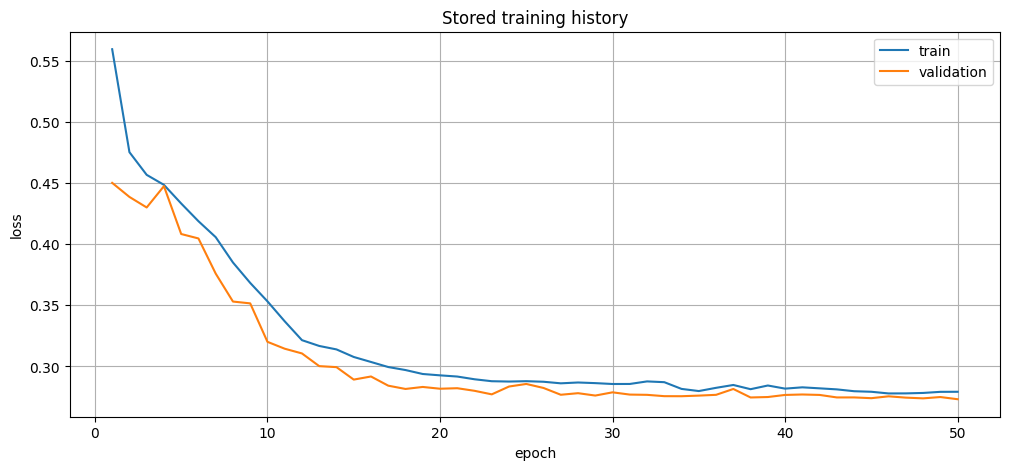

In [10]:
train_history = []
validation_history = []


with METRICS_PATH.open("r", encoding="utf-8") as file:
    for line in file:
        record = json.loads(line)

        if record.get("record_type") != "metrics":
            continue

        if record["split"] == "train":
            train_history.append(record)

        elif record["split"] == "validation":
            validation_history.append(record)


train_epochs = [
    record["epoch"]
    for record in train_history
]

train_losses = [
    record["metrics"]["loss_total"]
    for record in train_history
]

validation_epochs = [
    record["epoch"]
    for record in validation_history
]

validation_losses = [
    record["metrics"]["loss_total"]
    for record in validation_history
]


plt.figure(figsize=(12, 5))

plt.plot(
    train_epochs,
    train_losses,
    label="train",
)

plt.plot(
    validation_epochs,
    validation_losses,
    label="validation",
)

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Stored training history")
plt.grid(True)
plt.legend()
plt.show()

# 10: evaluation loss + physical metrics

In [11]:
def compute_evaluation_metrics(window, model_output):
    """Compute the same losses and physical error metrics used during training."""

    if window.targets is None:
        raise ValueError("Evaluation window has no targets.")

    total_loss = torch.zeros(
        (),
        dtype=MODEL_DTYPE,
        device=DEVICE,
    )

    metrics = {}
    num_heads = 0

    for calibration_key, prediction in model_output.predictions.items():
        target = window.targets[calibration_key]
        current_state = window.current_calibration[calibration_key]

        ##################################################
        # Reference correction
        ##################################################

        target_delta_transform = (
            target.next_transform
            @ torch.linalg.inv(current_state.transform)
        )

        target_delta_xi = se3_log(
            target_delta_transform
        )

        target_delta_tau = (
            target.next_time_offset
            - current_state.time_offset
        )

        ##################################################
        # Primary losses
        ##################################################

        rotation_loss = F.smooth_l1_loss(
            prediction.delta_xi[:, :3] / ROTATION_LOSS_SCALE_RAD,
            target_delta_xi[:, :3] / ROTATION_LOSS_SCALE_RAD,
        )

        translation_loss = F.smooth_l1_loss(
            prediction.delta_xi[:, 3:] / TRANSLATION_LOSS_SCALE_M,
            target_delta_xi[:, 3:] / TRANSLATION_LOSS_SCALE_M,
        )

        time_offset_loss = F.smooth_l1_loss(
            prediction.delta_tau / TIME_OFFSET_LOSS_SCALE_S,
            target_delta_tau / TIME_OFFSET_LOSS_SCALE_S,
        )

        ##################################################
        # Auxiliary event losses
        ##################################################

        change_labels = target.change_label.to(
            dtype=prediction.change_event_logit.dtype
        )

        change_event_loss = F.binary_cross_entropy_with_logits(
            prediction.change_event_logit,
            change_labels,
        )

        positive_event_mask = (
            change_labels[:, 0] > 0.5
        )

        if torch.any(positive_event_mask):
            change_time_loss = F.smooth_l1_loss(
                prediction.change_time[positive_event_mask]
                / CHANGE_TIME_LOSS_SCALE_S,
                target.change_time[positive_event_mask]
                / CHANGE_TIME_LOSS_SCALE_S,
            )
        else:
            change_time_loss = torch.zeros(
                (),
                dtype=MODEL_DTYPE,
                device=DEVICE,
            )

        ##################################################
        # Combined loss
        ##################################################

        head_loss = (
            ROTATION_LOSS_WEIGHT * rotation_loss
            + TRANSLATION_LOSS_WEIGHT * translation_loss
            + TIME_OFFSET_LOSS_WEIGHT * time_offset_loss
            + CHANGE_EVENT_LOSS_WEIGHT * change_event_loss
            + CHANGE_TIME_LOSS_WEIGHT * change_time_loss
        )

        total_loss = total_loss + head_loss
        num_heads += 1

        ##################################################
        # Physical metrics
        ##################################################

        rotation_error_rad = torch.linalg.vector_norm(
            prediction.delta_xi[:, :3]
            - target_delta_xi[:, :3],
            dim=-1,
        )

        translation_error_m = torch.linalg.vector_norm(
            prediction.delta_xi[:, 3:]
            - target_delta_xi[:, 3:],
            dim=-1,
        )

        time_offset_error_s = torch.abs(
            prediction.delta_tau[:, 0]
            - target_delta_tau[:, 0]
        )

        predicted_labels = (
            torch.sigmoid(
                prediction.change_event_logit[:, 0]
            )
            >= 0.5
        )

        true_labels = (
            change_labels[:, 0] >= 0.5
        )

        metrics[f"{calibration_key}/rotation_error_deg"] = torch.rad2deg(rotation_error_rad).mean().item()
        metrics[f"{calibration_key}/translation_error_cm"] = (100.0 * translation_error_m).mean().item()
        metrics[f"{calibration_key}/time_offset_error_ms"] = (1000.0 * time_offset_error_s).mean().item()

        metrics[f"{calibration_key}/loss_rotation"] = rotation_loss.item()
        metrics[f"{calibration_key}/loss_translation"] = translation_loss.item()
        metrics[f"{calibration_key}/loss_time_offset"] = time_offset_loss.item()
        metrics[f"{calibration_key}/loss_change_event"] = change_event_loss.item()
        metrics[f"{calibration_key}/loss_change_time"] = change_time_loss.item()

        metrics[f"{calibration_key}/event_accuracy"] = (
            predicted_labels == true_labels
        ).float().mean().item()

        if torch.any(true_labels):
            metrics[f"{calibration_key}/change_time_error_s"] = torch.abs(
                prediction.change_time[true_labels, 0]
                - target.change_time[true_labels, 0]
            ).mean().item()

    total_loss = (
        total_loss / num_heads
    )

    metrics["loss_total"] = total_loss.item()

    return metrics

# 11: recompute complete held-out test metrics

In [12]:
def evaluate_loader(loader, augmentation_seed):
    """Evaluate all windows while weighting minibatch metrics by sample count."""

    model.eval()

    augmentation_generator = make_augmentation_generator(
        augmentation_seed
    )

    metric_sums = {}
    num_samples = 0

    with torch.no_grad():
        for base_window in loader:
            base_window = window_batch_to(
                base_window,
                DEVICE,
                dtype=MODEL_DTYPE,
            )

            augmentation_result = augmentation_pipeline(
                base_window,
                generator=augmentation_generator,
            )

            evaluation_window = (
                augmentation_result.augmented_window
            )

            result = window_step(
                evaluation_window
            )

            metrics = compute_evaluation_metrics(
                evaluation_window,
                result.model_output,
            )

            batch_size = next(
                iter(evaluation_window.streams.values())
            ).values.shape[0]

            for key, value in metrics.items():
                metric_sums[key] = (
                    metric_sums.get(key, 0.0)
                    + value * batch_size
                )

            num_samples += batch_size

    return {
        key: value / num_samples
        for key, value in metric_sums.items()
    }


test_metrics = evaluate_loader(
    test_loader,
    TEST_AUGMENTATION_SEED,
)


for key, value in sorted(test_metrics.items()):
    print(f"{key}: {value}")

imu/change_time_error_s: 0.4745388413151951
imu/event_accuracy: 0.46382978723404256
imu/loss_change_event: 0.6937388586659804
imu/loss_change_time: 0.007663242536075149
imu/loss_rotation: 0.05389198325838603
imu/loss_time_offset: 0.02325586372035298
imu/loss_translation: 0.03032101446115379
imu/rotation_error_deg: 7.2670836184887175
imu/time_offset_error_ms: 3.3931699245534044
imu/translation_error_cm: 7.090700631107844
lidar/change_time_error_s: 0.4377863309062119
lidar/event_accuracy: 0.5333333333333333
lidar/loss_change_event: 0.6925261662361469
lidar/loss_change_time: 0.006953182714956801
lidar/loss_rotation: 0.050576000947320295
lidar/loss_time_offset: 0.01790318396417193
lidar/loss_translation: 0.02983007532220783
lidar/rotation_error_deg: 6.922643318582089
lidar/time_offset_error_ms: 2.9290155522366788
lidar/translation_error_cm: 6.974979978250274
loss_total: 0.2779992402022612


/home/camel/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


# 12: choose consecutive windows from one test sequence

In [13]:
sequence_indices = [
    index
    for index in range(len(test_dataset))
    if test_dataset.sequence_name_for_window(index) == VIS_SEQUENCE_NAME
]


if not sequence_indices:
    raise ValueError(
        f"Sequence {VIS_SEQUENCE_NAME!r} was not found."
    )


selected_indices = sequence_indices[
    VIS_START_WINDOW :
    VIS_START_WINDOW + VIS_NUM_WINDOWS
]


print("Sequence:", VIS_SEQUENCE_NAME)
print("Selected windows:", len(selected_indices))
print(
    "Dataset range:",
    selected_indices[0],
    "...",
    selected_indices[-1],
)

Sequence: Urban38
Selected windows: 80
Dataset range: 0 ... 79


# 13: collect reference and predicted calibration corrections

In [14]:
def collect_calibration_predictions(
    dataset,
    indices,
    *,
    batch_size,
    augmentation_seed,
):
    """Collect target and predicted corrections for selected windows."""

    augmentation_generator = make_augmentation_generator(
        augmentation_seed
    )

    collected = {
        calibration_key: {
            "reference_delta_xi": [],
            "predicted_delta_xi": [],
            "reference_delta_tau": [],
            "predicted_delta_tau": [],
            "event_label": [],
            "event_probability": [],
            "reference_change_time": [],
            "predicted_change_time": [],
        }
        for calibration_key in model_config.head_keys
    }

    model.eval()

    with torch.no_grad():
        for start_index in range(
            0,
            len(indices),
            batch_size,
        ):
            batch_indices = indices[
                start_index :
                start_index + batch_size
            ]

            base_window = collate_windows(
                [
                    dataset[index]
                    for index in batch_indices
                ]
            )

            base_window = window_batch_to(
                base_window,
                DEVICE,
                dtype=MODEL_DTYPE,
            )

            augmentation_result = augmentation_pipeline(
                base_window,
                generator=augmentation_generator,
            )

            augmented_window = (
                augmentation_result.augmented_window
            )

            result = window_step(
                augmented_window
            )

            for calibration_key, prediction in result.model_output.predictions.items():
                target = (
                    augmented_window.targets[
                        calibration_key
                    ]
                )

                current_state = (
                    augmented_window.current_calibration[
                        calibration_key
                    ]
                )

                reference_delta_transform = (
                    target.next_transform
                    @ torch.linalg.inv(
                        current_state.transform
                    )
                )

                reference_delta_xi = se3_log(
                    reference_delta_transform
                )

                reference_delta_tau = (
                    target.next_time_offset
                    - current_state.time_offset
                )

                collected[calibration_key]["reference_delta_xi"].append(
                    reference_delta_xi.cpu()
                )

                collected[calibration_key]["predicted_delta_xi"].append(
                    prediction.delta_xi.cpu()
                )

                collected[calibration_key]["reference_delta_tau"].append(
                    reference_delta_tau.cpu()
                )

                collected[calibration_key]["predicted_delta_tau"].append(
                    prediction.delta_tau.cpu()
                )

                collected[calibration_key]["event_label"].append(
                    target.change_label.cpu()
                )

                collected[calibration_key]["event_probability"].append(
                    torch.sigmoid(
                        prediction.change_event_logit
                    ).cpu()
                )

                collected[calibration_key]["reference_change_time"].append(
                    target.change_time.cpu()
                )

                collected[calibration_key]["predicted_change_time"].append(
                    prediction.change_time.cpu()
                )

    for calibration_key in collected:
        for field_name in collected[calibration_key]:
            collected[calibration_key][field_name] = torch.cat(
                collected[calibration_key][field_name],
                dim=0,
            ).numpy()

    return collected


visualization_results = collect_calibration_predictions(
    test_dataset,
    selected_indices,
    batch_size=VIS_BATCH_SIZE,
    augmentation_seed=VIS_AUGMENTATION_SEED,
)

# 14: plot all seven calibration correction components

In [31]:
CALIBRATION_COMPONENT_NAMES = (
    "phi_x",
    "phi_y",
    "phi_z",
    "rho_x",
    "rho_y",
    "rho_z",
)


def plot_calibration_corrections(
    results,
    calibration_key,
):
    result = results[
        calibration_key
    ]

    reference_xi = result[
        "reference_delta_xi"
    ]

    predicted_xi = result[
        "predicted_delta_xi"
    ]

    reference_tau = result[
        "reference_delta_tau"
    ][:, 0]

    predicted_tau = result[
        "predicted_delta_tau"
    ][:, 0]

    times_s = (
        np.arange(len(reference_xi))
        * WINDOW_STRIDE_S
    )

    fig, axes = plt.subplots(
        7,
        1,
        figsize=(15, 16),
        sharex=True,
    )

    ##################################################
    # Rotation
    ##################################################

    for component_index in range(3):
        axes[component_index].plot(
            times_s,
            np.zeros_like(times_s),
            label="initial",
        )

        axes[component_index].plot(
            times_s,
            np.rad2deg(
                reference_xi[:, component_index]
            ),
            label="reference",
        )

        axes[component_index].plot(
            times_s,
            np.rad2deg(
                predicted_xi[:, component_index]
            ),
            label="predicted",
        )

        axes[component_index].set_ylabel(
            f"{CALIBRATION_COMPONENT_NAMES[component_index]} [deg]"
        )

        axes[component_index].grid(True)
        axes[component_index].legend()

    ##################################################
    # Translational tangent
    ##################################################

    for component_index in range(3, 6):
        axes[component_index].plot(
            times_s,
            np.zeros_like(times_s),
            label="initial",
        )

        axes[component_index].plot(
            times_s,
            100.0
            * reference_xi[:, component_index],
            label="reference",
        )

        axes[component_index].plot(
            times_s,
            100.0
            * predicted_xi[:, component_index],
            label="predicted",
        )

        axes[component_index].set_ylabel(
            f"{CALIBRATION_COMPONENT_NAMES[component_index]} [cm]"
        )

        axes[component_index].grid(True)
        axes[component_index].legend()

    ##################################################
    # Temporal correction
    ##################################################

    axes[-1].plot(
        times_s,
        np.zeros_like(times_s),
        label="initial",
    )

    axes[-1].plot(
        times_s,
        1000.0 * reference_tau,
        label="reference",
    )

    axes[-1].plot(
        times_s,
        1000.0 * predicted_tau,
        label="predicted",
    )

    axes[-1].set_ylabel("delta_tau [ms]")
    axes[-1].set_xlabel("sequence time [s]")

    axes[-1].grid(True)
    axes[-1].legend()

    fig.suptitle(
        f"{VIS_SEQUENCE_NAME}: {calibration_key} calibration correction"
    )

    fig.tight_layout()
    plt.show()

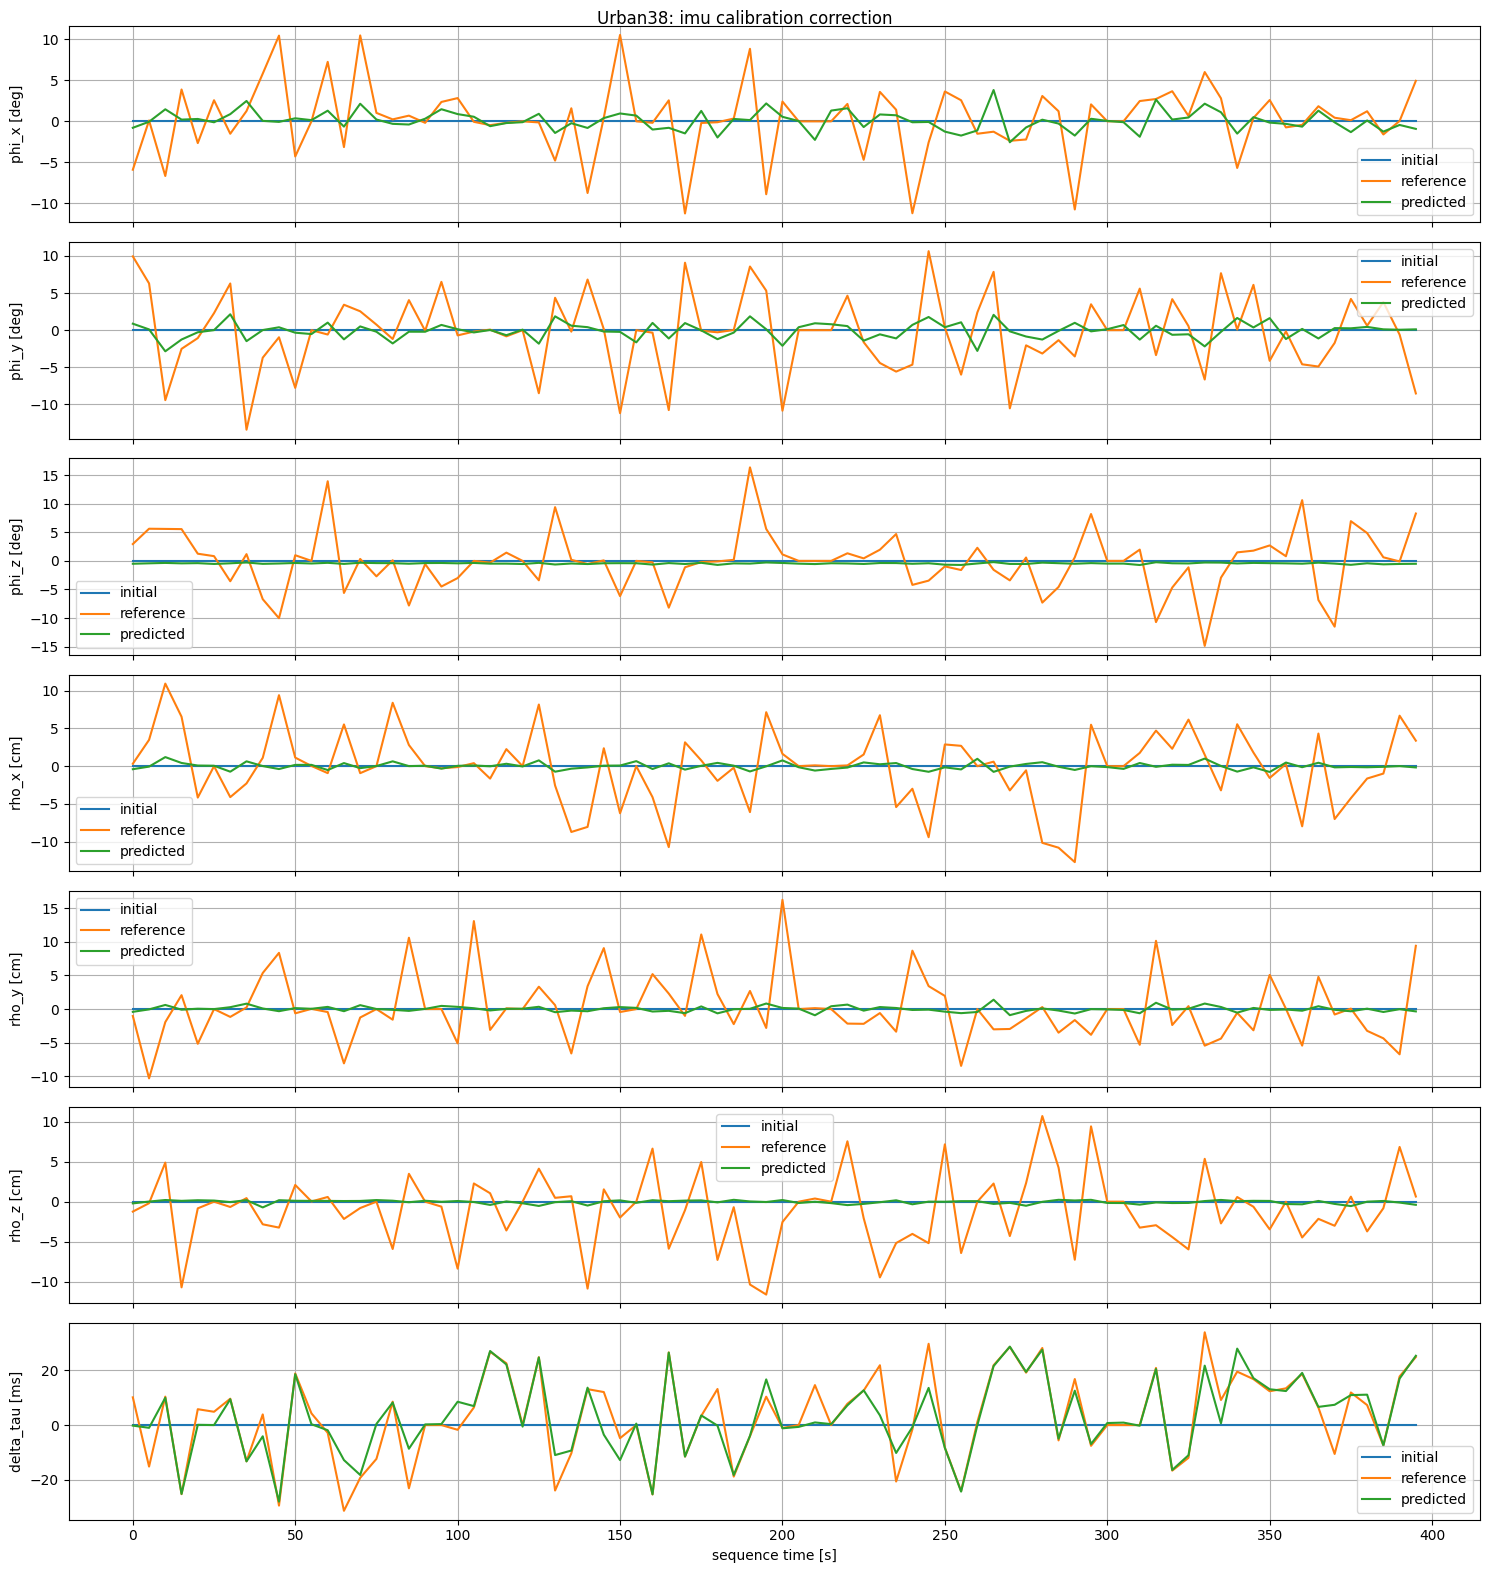

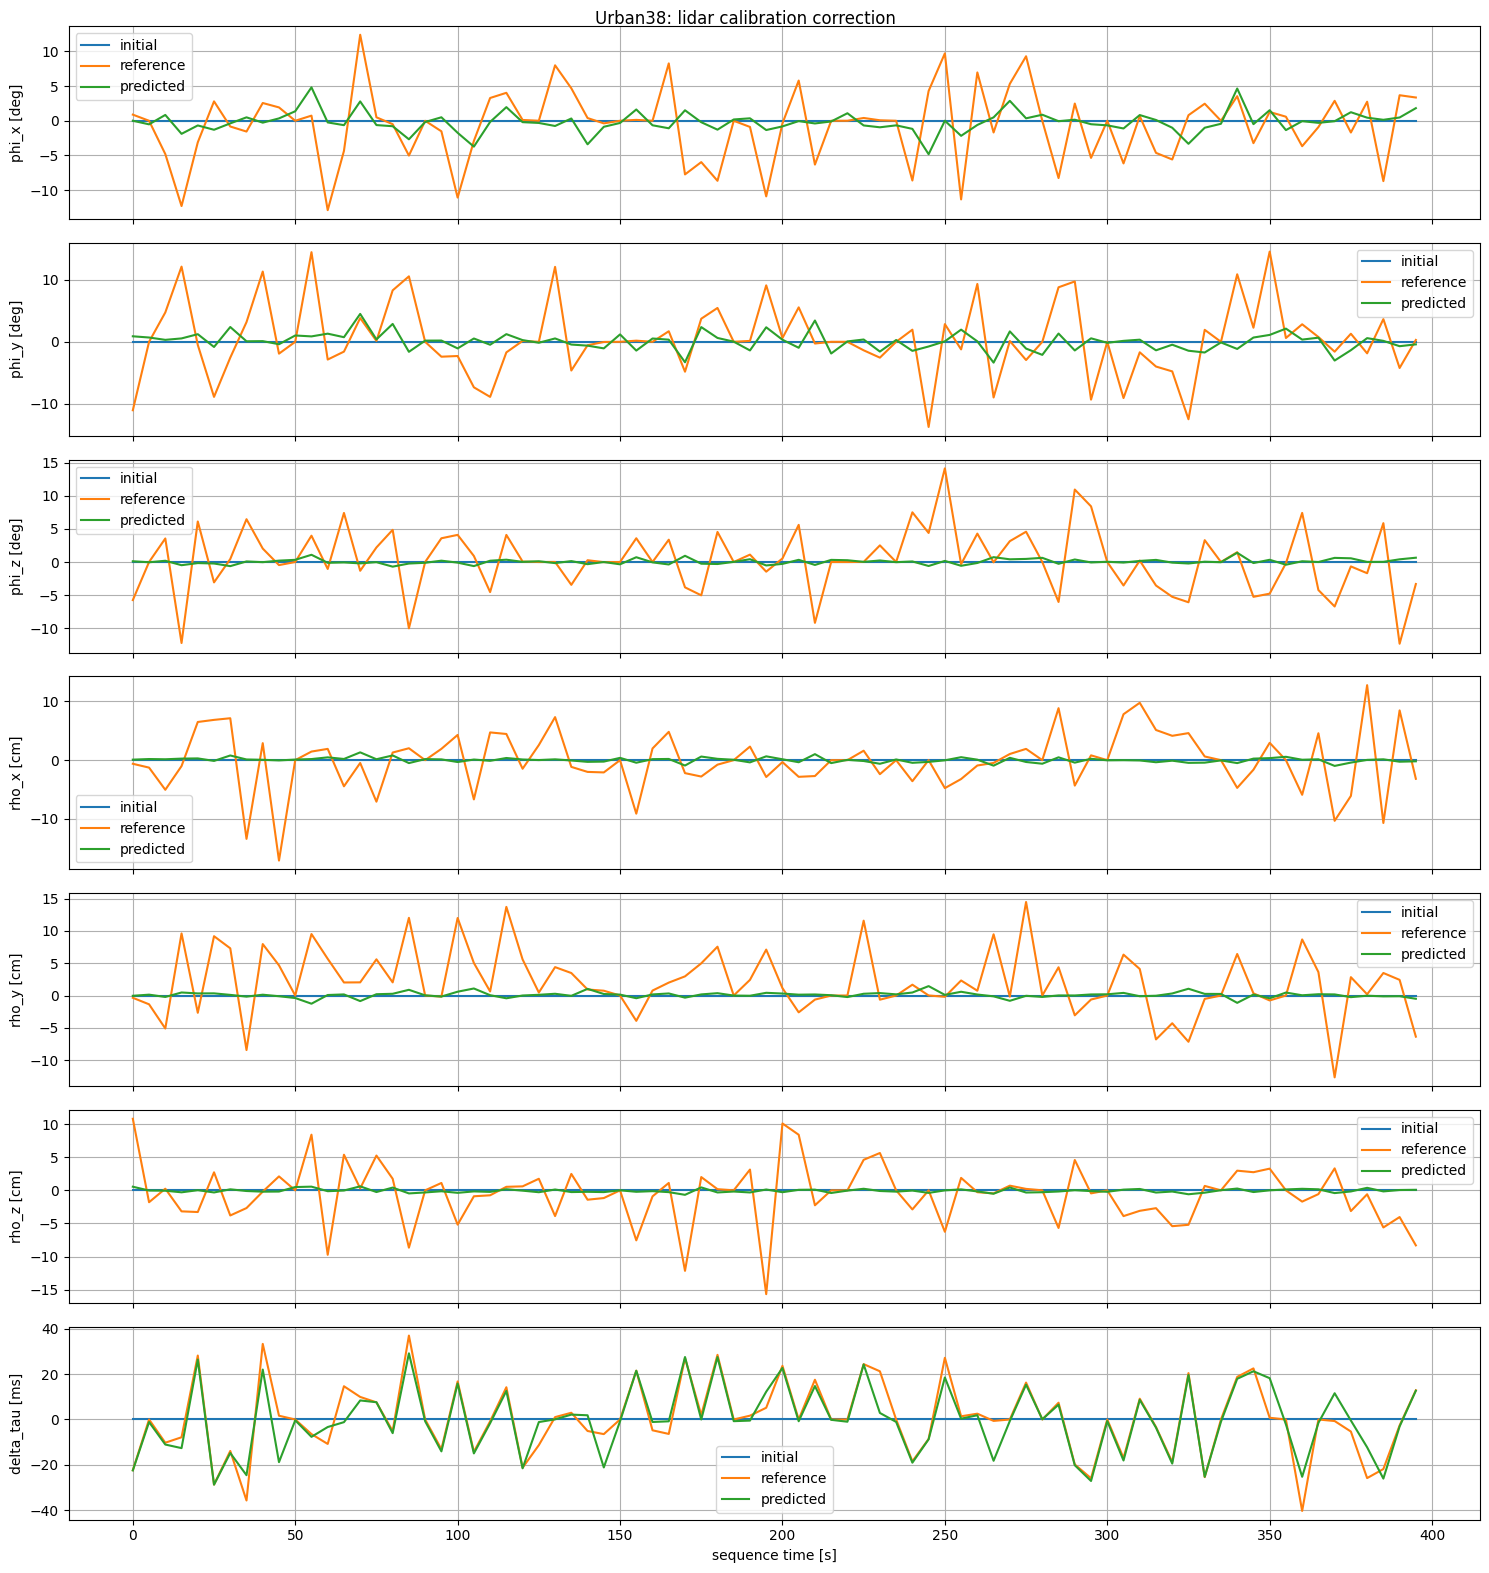

In [32]:
plot_calibration_corrections(
    visualization_results,
    "imu",
)

plot_calibration_corrections(
    visualization_results,
    "lidar",
)

# 15: compare the model against the zero-correction baseline

In [17]:
def print_initial_vs_predicted_error(
    results,
    calibration_key,
):
    result = results[
        calibration_key
    ]

    reference_xi = result[
        "reference_delta_xi"
    ]

    predicted_xi = result[
        "predicted_delta_xi"
    ]

    reference_tau = result[
        "reference_delta_tau"
    ][:, 0]

    predicted_tau = result[
        "predicted_delta_tau"
    ][:, 0]

    ##################################################
    # Initial calibration means correction = zero
    ##################################################

    initial_rotation_error_deg = np.rad2deg(
        np.linalg.norm(
            reference_xi[:, :3],
            axis=1,
        )
    )

    predicted_rotation_error_deg = np.rad2deg(
        np.linalg.norm(
            predicted_xi[:, :3]
            - reference_xi[:, :3],
            axis=1,
        )
    )

    initial_translation_error_cm = (
        100.0
        * np.linalg.norm(
            reference_xi[:, 3:],
            axis=1,
        )
    )

    predicted_translation_error_cm = (
        100.0
        * np.linalg.norm(
            predicted_xi[:, 3:]
            - reference_xi[:, 3:],
            axis=1,
        )
    )

    initial_tau_error_ms = (
        1000.0
        * np.abs(
            reference_tau
        )
    )

    predicted_tau_error_ms = (
        1000.0
        * np.abs(
            predicted_tau
            - reference_tau
        )
    )

    print(calibration_key)
    print()

    print(
        f"rotation:    initial={initial_rotation_error_deg.mean():.3f} deg, "
        f"predicted={predicted_rotation_error_deg.mean():.3f} deg"
    )

    print(
        f"translation: initial={initial_translation_error_cm.mean():.3f} cm, "
        f"predicted={predicted_translation_error_cm.mean():.3f} cm"
    )

    print(
        f"time offset: initial={initial_tau_error_ms.mean():.3f} ms, "
        f"predicted={predicted_tau_error_ms.mean():.3f} ms"
    )

In [18]:
print_initial_vs_predicted_error(
    visualization_results,
    "imu",
)

print()

print_initial_vs_predicted_error(
    visualization_results,
    "lidar",
)

imu

rotation:    initial=6.749 deg, predicted=6.690 deg
translation: initial=6.791 cm, predicted=6.800 cm
time offset: initial=13.014 ms, predicted=3.740 ms

lidar

rotation:    initial=7.285 deg, predicted=7.321 deg
translation: initial=7.044 cm, predicted=7.073 cm
time offset: initial=11.722 ms, predicted=3.595 ms


# 16: event-head diagnostics

In [19]:
def plot_event_predictions(
    results,
    calibration_key,
):
    result = results[
        calibration_key
    ]

    event_label = result[
        "event_label"
    ][:, 0]

    event_probability = result[
        "event_probability"
    ][:, 0]

    reference_change_time = result[
        "reference_change_time"
    ][:, 0]

    predicted_change_time = result[
        "predicted_change_time"
    ][:, 0]

    times_s = (
        np.arange(len(event_label))
        * WINDOW_STRIDE_S
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(15, 7),
        sharex=True,
    )

    axes[0].step(
        times_s,
        event_label,
        where="mid",
        label="reference event",
    )

    axes[0].plot(
        times_s,
        event_probability,
        label="predicted probability",
    )

    axes[0].axhline(
        0.5,
        linestyle="--",
        label="threshold",
    )

    axes[0].set_ylim(
        -0.05,
        1.05,
    )

    axes[0].set_ylabel("event")
    axes[0].grid(True)
    axes[0].legend()

    event_mask = (
        event_label > 0.5
    )

    axes[1].plot(
        times_s[event_mask],
        reference_change_time[event_mask],
        marker="o",
        label="reference",
    )

    axes[1].plot(
        times_s[event_mask],
        predicted_change_time[event_mask],
        marker="o",
        label="predicted",
    )

    axes[1].set_ylabel(
        "change time within window [s]"
    )

    axes[1].set_xlabel(
        "sequence time [s]"
    )

    axes[1].grid(True)
    axes[1].legend()

    fig.suptitle(
        f"{VIS_SEQUENCE_NAME}: {calibration_key} event prediction"
    )

    fig.tight_layout()
    plt.show()

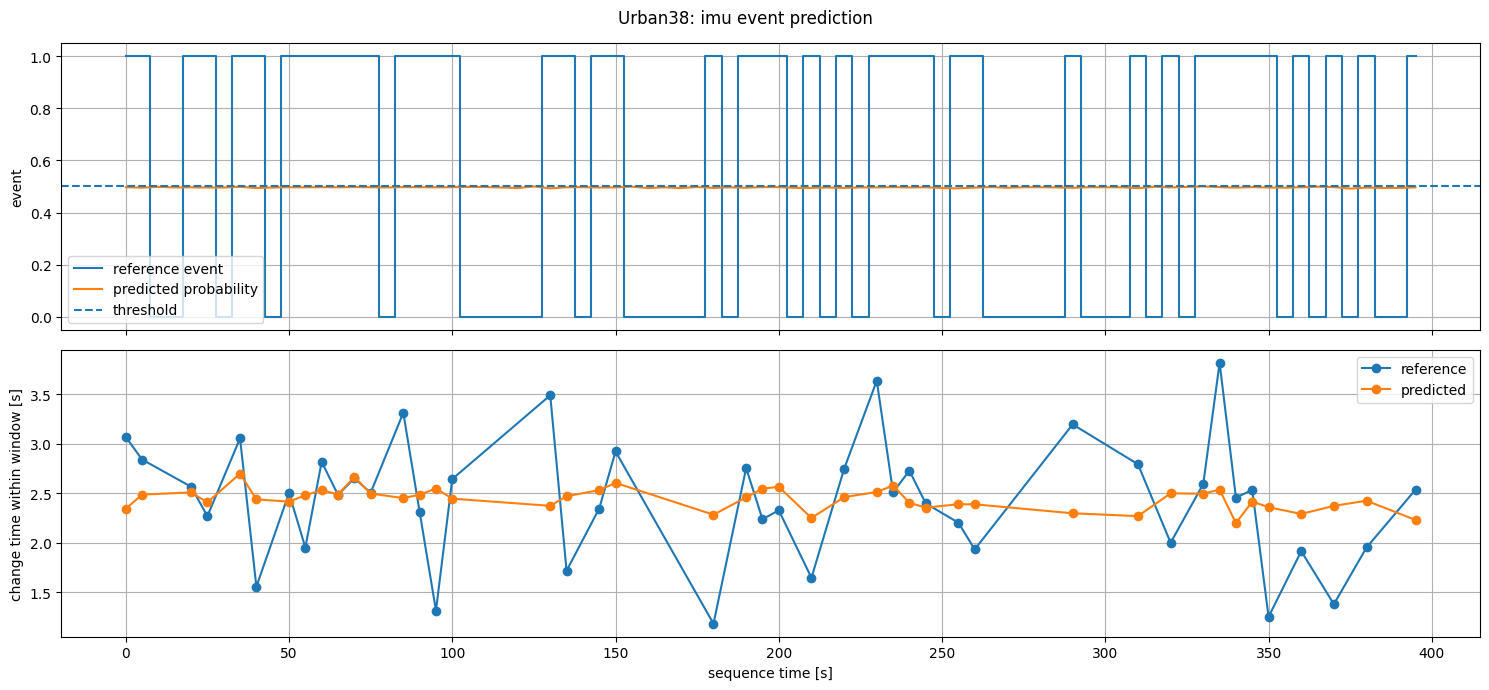

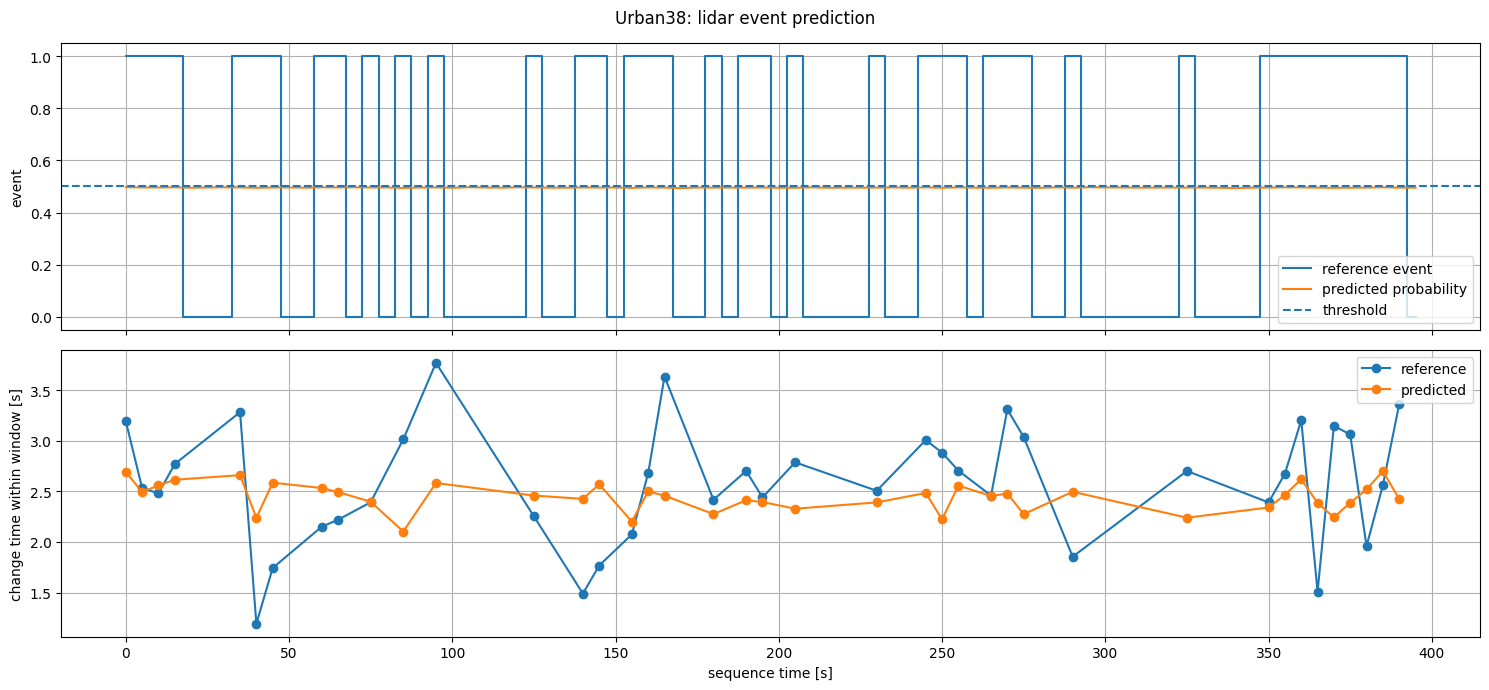

In [20]:
plot_event_predictions(
    visualization_results,
    "imu",
)

plot_event_predictions(
    visualization_results,
    "lidar",
)

# 17: create a static-calibration diagnostic pipeline

In [21]:
static_visualization_config = replace(
    augmentation_config,

    calibration_event=CalibrationEventConfig(
        enabled=False,
    ),
)


static_visualization_pipeline = AugmentationPipeline(
    static_visualization_config
)

# 18: run one real test window through initial/reference/predicted calibration

In [22]:
STATIC_VIS_WINDOW_INDEX = sequence_indices[
    VIS_START_WINDOW
]

STATIC_VIS_SEED = 67890


base_window = collate_windows(
    [
        test_dataset[
            STATIC_VIS_WINDOW_INDEX
        ]
    ]
)


base_window = window_batch_to(
    base_window,
    DEVICE,
    dtype=MODEL_DTYPE,
)


static_result = static_visualization_pipeline(
    base_window,
    generator=make_augmentation_generator(
        STATIC_VIS_SEED
    ),
)


static_window = (
    static_result.augmented_window
)


with torch.no_grad():
    prediction_result = window_step(
        static_window
    )


##################################################
# Initial calibration supplied to the network
##################################################

initial_calibration = (
    static_window.current_calibration
)


##################################################
# True reference calibration
##################################################

reference_calibration = {
    calibration_key: CalibrationState(
        transform=target.next_transform,
        time_offset=target.next_time_offset,
    )
    for calibration_key, target
    in static_window.targets.items()
}


##################################################
# Network-predicted next calibration
##################################################

predicted_calibration = (
    prediction_result.next_calibration
)


print("Window dataset index:", STATIC_VIS_WINDOW_INDEX)

Window dataset index: 0


# 19: canonicalize the same raw signals using all three calibrations

In [23]:
with torch.no_grad():
    canonical_initial = geometry_processor(
        static_window.streams,
        static_window.metadata,
        initial_calibration,
    )

    canonical_reference = geometry_processor(
        static_window.streams,
        static_window.metadata,
        reference_calibration,
    )

    canonical_predicted = geometry_processor(
        static_window.streams,
        static_window.metadata,
        predicted_calibration,
    )

# 20: helper for plotting canonical sensor signals

In [24]:
def valid_canonical_stream(
    canonical_streams,
    stream_key,
):
    stream = canonical_streams[
        stream_key
    ]

    mask = stream.sample_mask[0]

    timestamps = (
        stream.timestamps[
            0,
            mask,
        ]
        .detach()
        .cpu()
        .numpy()
    )

    values = (
        stream.values[
            0,
            mask,
        ]
        .detach()
        .cpu()
        .numpy()
    )

    return timestamps, values


def plot_canonical_signal_comparison(
    stream_key,
    component_names,
    title,
):
    initial_t, initial_values = valid_canonical_stream(
        canonical_initial,
        stream_key,
    )

    reference_t, reference_values = valid_canonical_stream(
        canonical_reference,
        stream_key,
    )

    predicted_t, predicted_values = valid_canonical_stream(
        canonical_predicted,
        stream_key,
    )

    num_components = initial_values.shape[-1]

    fig, axes = plt.subplots(
        num_components,
        1,
        figsize=(15, 2.5 * num_components),
        sharex=False,
    )

    if num_components == 1:
        axes = [axes]

    for component_index in range(num_components):
        axes[component_index].plot(
            initial_t,
            initial_values[:, component_index],
            label="initial calibration",
        )

        axes[component_index].plot(
            reference_t,
            reference_values[:, component_index],
            label="reference calibration",
        )

        axes[component_index].plot(
            predicted_t,
            predicted_values[:, component_index],
            label="predicted calibration",
        )

        axes[component_index].set_ylabel(
            component_names[
                component_index
            ]
        )

        axes[component_index].grid(True)
        axes[component_index].legend()

    axes[-1].set_xlabel(
        "corrected time [s]"
    )

    fig.suptitle(
        title
    )

    fig.tight_layout()
    plt.show()

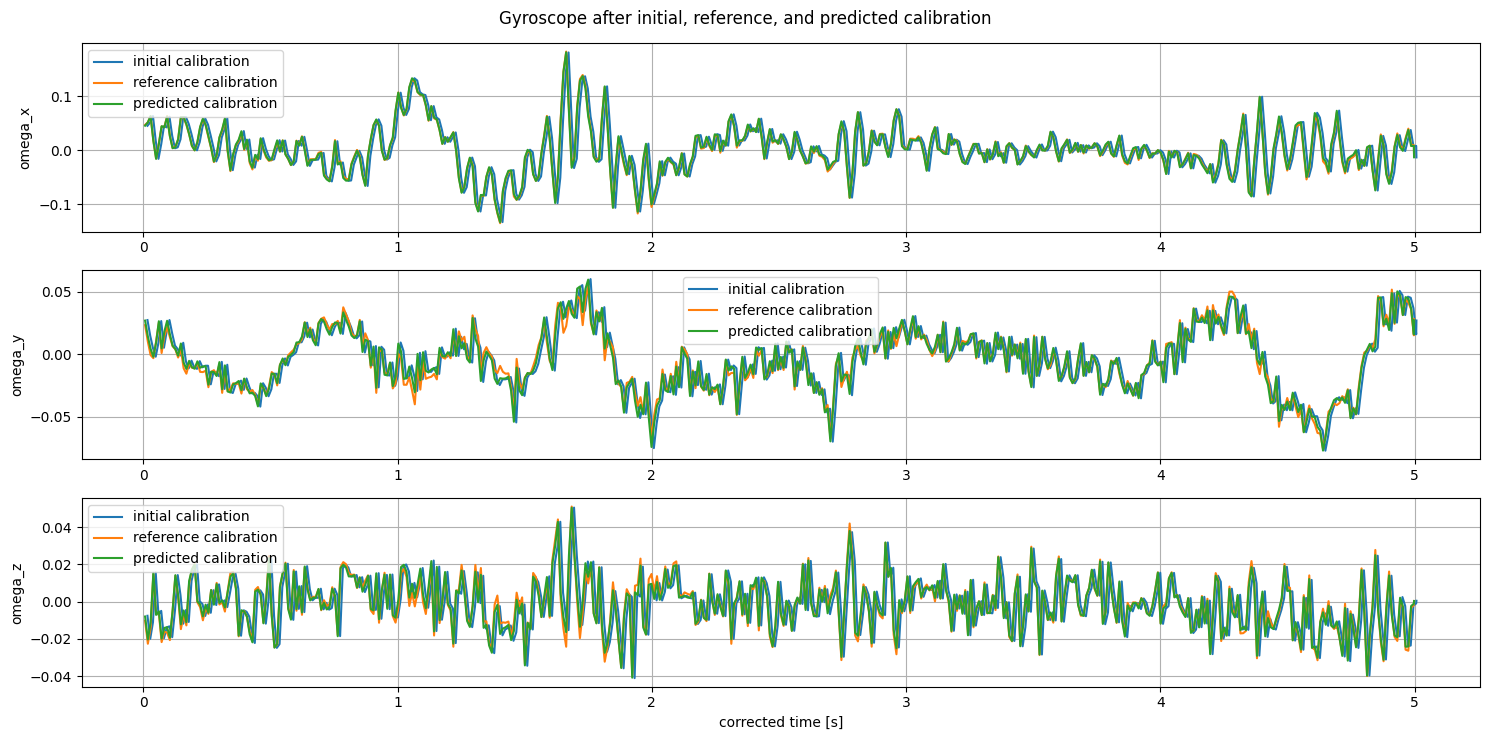

In [25]:
plot_canonical_signal_comparison(
    "gyro",
    (
        "omega_x",
        "omega_y",
        "omega_z",
    ),
    "Gyroscope after initial, reference, and predicted calibration",
)

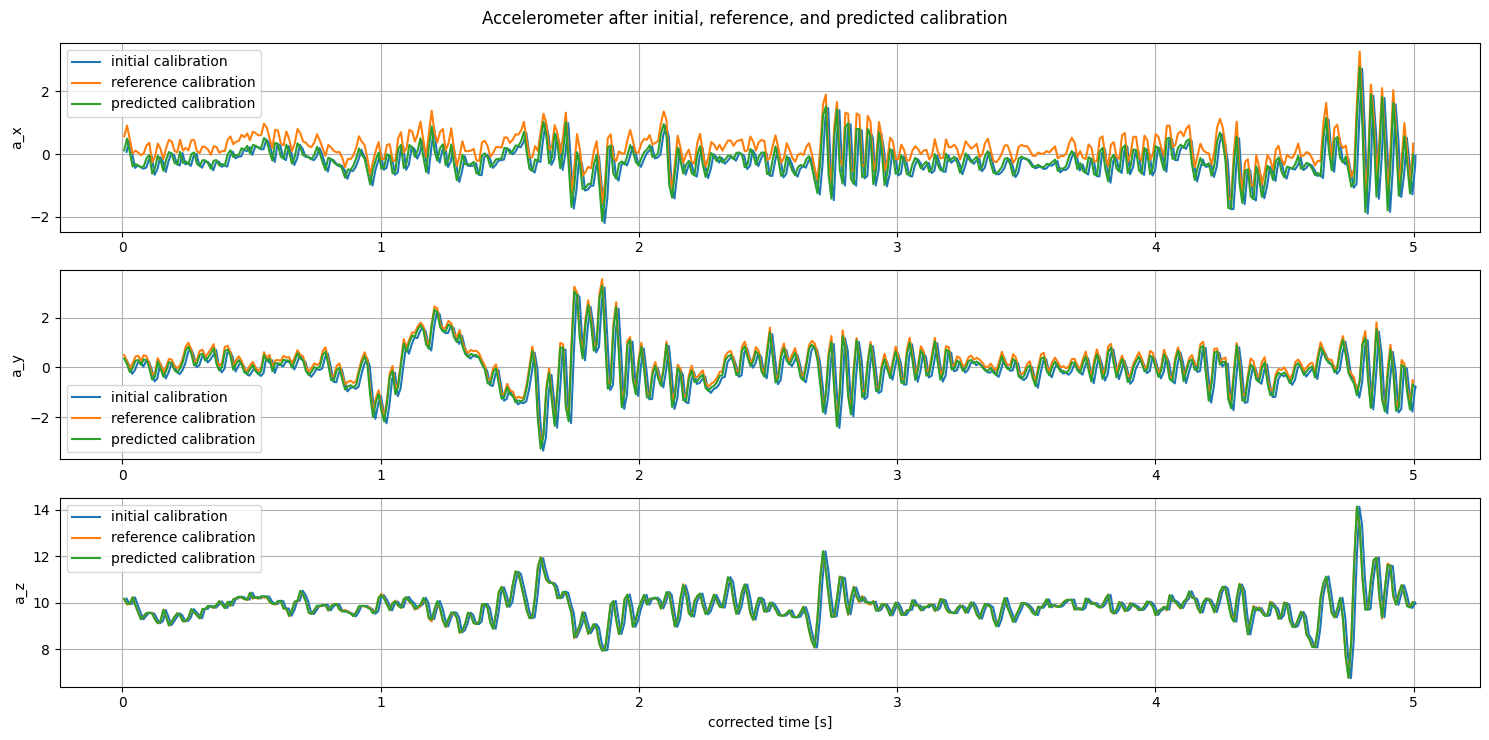

In [26]:
plot_canonical_signal_comparison(
    "accel",
    (
        "a_x",
        "a_y",
        "a_z",
    ),
    "Accelerometer after initial, reference, and predicted calibration",
)

# 23: LiDAR relative-motion signal

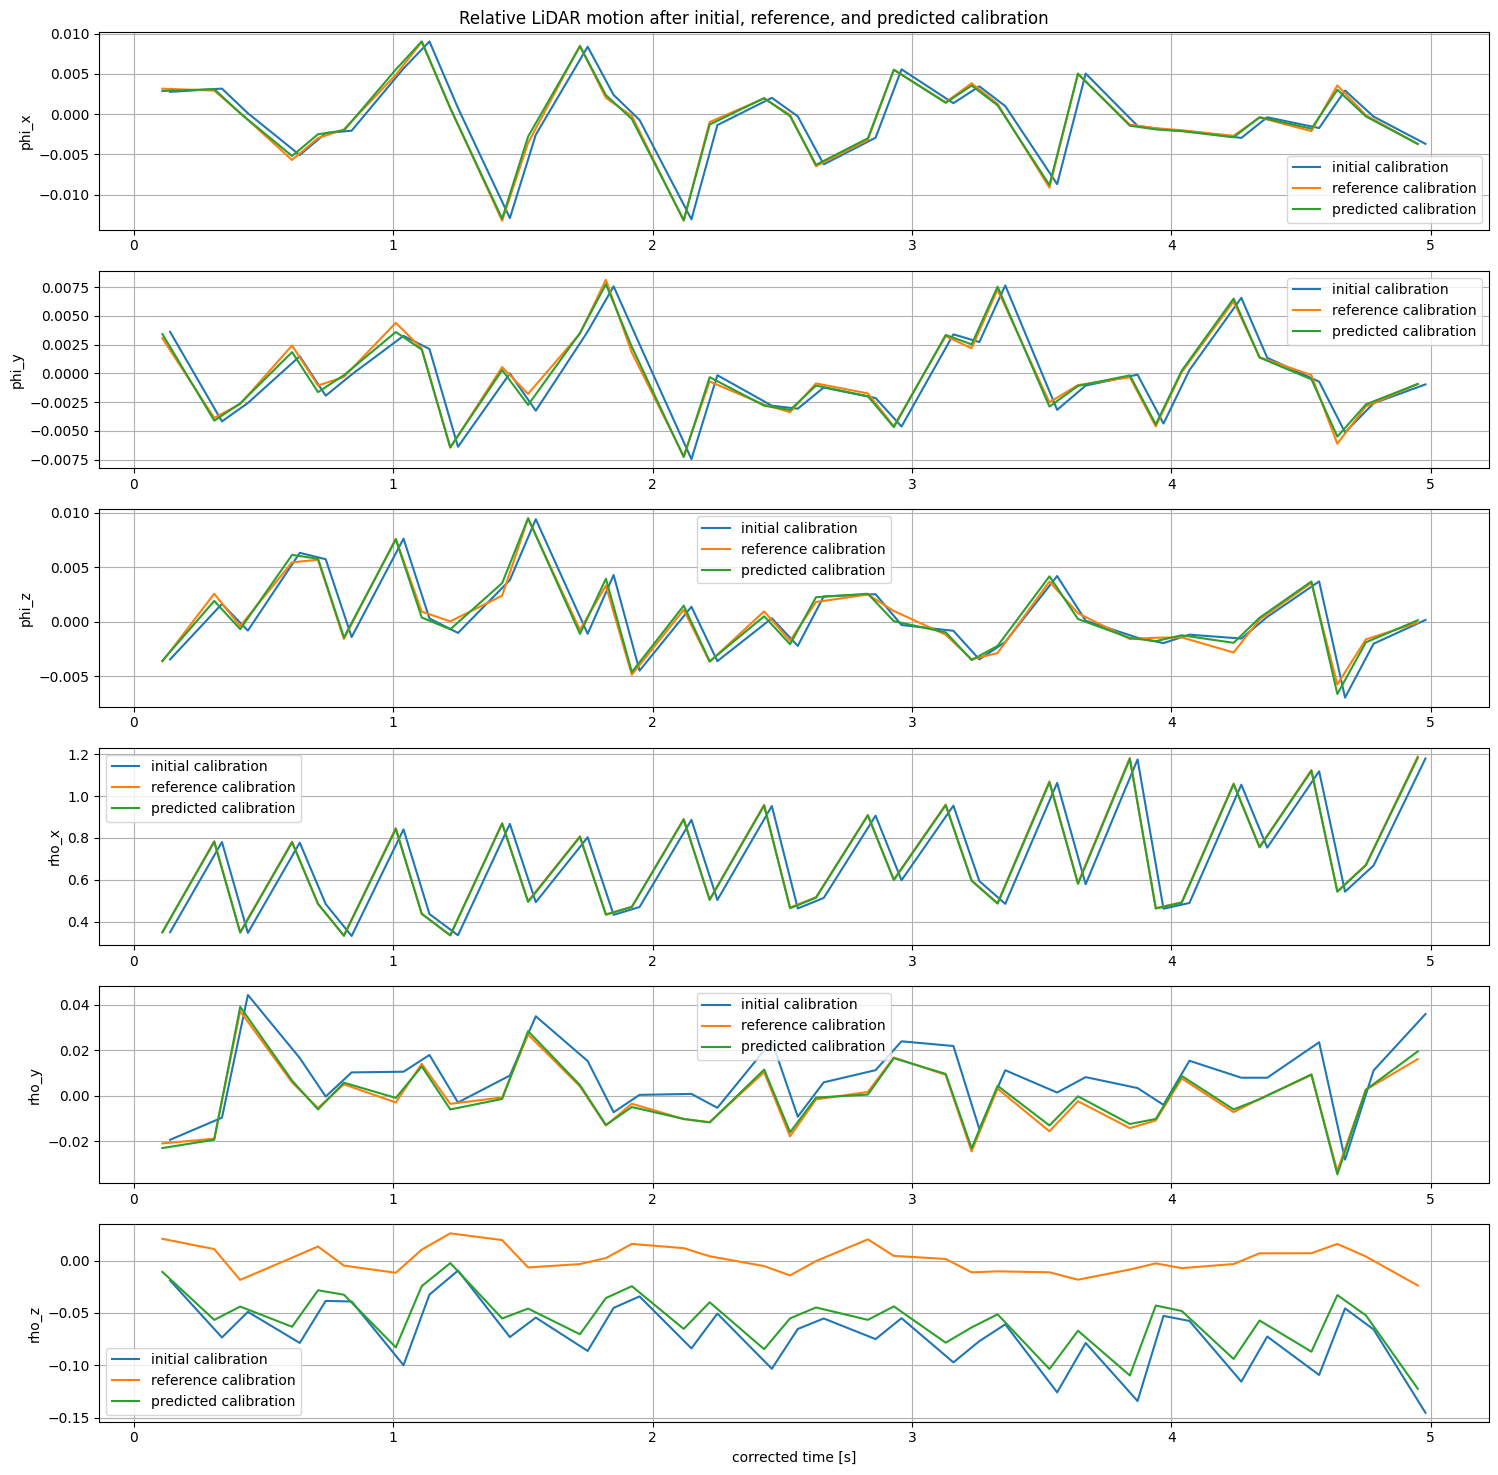

In [28]:
plot_canonical_signal_comparison(
    "lidar",
    (
        "phi_x",
        "phi_y",
        "phi_z",
        "rho_x",
        "rho_y",
        "rho_z",
    ),
    "Relative LiDAR motion after initial, reference, and predicted calibration",
)

In [33]:
def print_prediction_collapse_diagnostics(results, calibration_key):
    result = results[calibration_key]

    reference_xi = result["reference_delta_xi"]
    predicted_xi = result["predicted_delta_xi"]

    names = (
        "phi_x",
        "phi_y",
        "phi_z",
        "rho_x",
        "rho_y",
        "rho_z",
    )

    print(calibration_key)
    print()

    for index, name in enumerate(names):
        target = reference_xi[:, index]
        prediction = predicted_xi[:, index]

        if np.std(target) > 0.0 and np.std(prediction) > 0.0:
            correlation = np.corrcoef(target, prediction)[0, 1]
        else:
            correlation = np.nan

        print(
            f"{name:5s}  "
            f"target std={np.std(target):.5f}  "
            f"pred std={np.std(prediction):.5f}  "
            f"corr={correlation:+.3f}"
        )


print_prediction_collapse_diagnostics(
    visualization_results,
    "imu",
)

print()

print_prediction_collapse_diagnostics(
    visualization_results,
    "lidar",
)

imu

phi_x  target std=0.07437  pred std=0.02029  corr=+0.279
phi_y  target std=0.08999  pred std=0.01848  corr=+0.464
phi_z  target std=0.09013  pred std=0.00186  corr=-0.171
rho_x  target std=0.04828  pred std=0.00429  corr=+0.291
rho_y  target std=0.04868  pred std=0.00413  corr=+0.066
rho_z  target std=0.04471  pred std=0.00215  corr=+0.026

lidar

phi_x  target std=0.08836  pred std=0.02620  corr=+0.275
phi_y  target std=0.10173  pred std=0.02426  corr=+0.235
phi_z  target std=0.08280  pred std=0.00680  corr=+0.088
rho_x  target std=0.05047  pred std=0.00412  corr=+0.132
rho_y  target std=0.04977  pred std=0.00428  corr=+0.009
rho_z  target std=0.04425  pred std=0.00270  corr=+0.235
